# 7주차_데이터 전처리와 파생변수 생성 Ⅱ

- 슬라이딩 윈도우 데이터 가공 

---

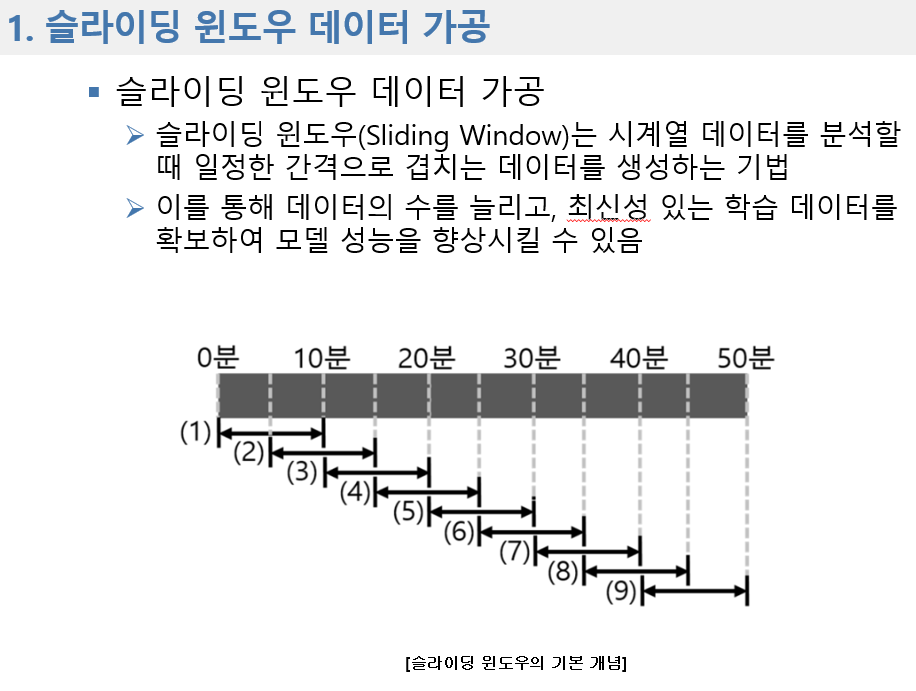

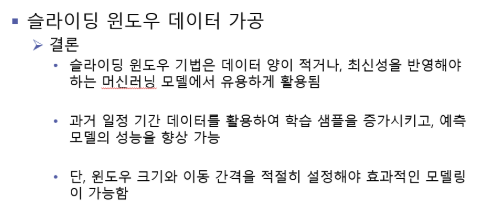

In [1]:
# 필요한 패키지 설치
from dateutil.relativedelta import relativedelta
# datetime 객체 간의 차이를 개월 수, 연도 수 단위 등으로 계산할 수 있게 해주는 유틸리티 모듈을 임포트함
# 예: 날짜 간의 정확한 월/년 단위 차이 계산, 특정 날짜 기준 ±n개월 계산 등에 유용함

import numpy as np
# 수치 계산, 배열 처리, 난수 생성 등 과학 계산을 위한 핵심 라이브러리 numpy를 임포트함
# 머신러닝, 통계 분석, 벡터화 연산 등에서 널리 사용됨

import pandas as pd
# 데이터 분석과 조작을 위한 고수준의 라이브러리인 pandas를 임포트함
# 표 형식의 데이터 처리, 결측값 처리, 그룹 연산 등에서 중심적으로 사용됨

# plt.rcParams['figure.dpi'] = 300
# (주석 처리됨) 시각화 그래프의 해상도(DPI)를 300으로 설정하는 코드임
# 고해상도 출력이 필요할 경우 주석을 해제하여 그래프 품질을 향상시킬 수 있음

In [2]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/shopping-mall
df_raw=pd.read_csv("../../main/datasets/shopping_mall.csv")

# 데이터 샘플 확인
df_raw.head()

,cust_id,dt,ym,sale_amt
0,AFG4127094465,2021-12-09,202112,300000
1,AFG4127094465,2022-04-22,202204,45000
2,AFG4136725677,2022-04-07,202204,47800
3,AFG4140129314,2022-02-07,202202,39200
4,AFG4144923657,2022-05-11,202205,110000


In [3]:
# 각 시점 기준 컬럼 생성

# 날짜형으로 변환
df_raw['Date2'] = pd.to_datetime(df_raw['dt'])
# 문자열 또는 object 타입으로 되어 있는 'dt' 컬럼을 pandas의 datetime 형식으로 변환하여 'Date2'에 저장함
# 이후 날짜 연산이 가능하도록 타입을 표준화함

# 시점변수 생성
ym_li = [f"YM_M{i}" for i in range(6)]
# 'YM_M0'부터 'YM_M5'까지 6개의 시점 변수명을 문자열 리스트로 생성함
# 이 변수들은 기준일을 중심으로 각각 0개월 전, 1개월 전, ..., 5개월 전의 상대적 시점을 의미함

for i in range(len(ym_li)):
    col = ym_li[i]
    # 반복문 인덱스를 통해 시점별 컬럼명을 지정함

    now = pd.to_datetime('2022-05-01') + relativedelta(months=-i)
    # 기준일인 2022년 5월 1일로부터 i개월 전 날짜를 계산함
    # relativedelta를 사용하여 정확한 달 단위 연산을 수행함 (예: 윤달, 월말 처리 등)

    df_raw[col] = 'M' + (
        -np.floor((df_raw.Date2 - now) / np.timedelta64(1, 'D') / 30.4375)
    ).astype(int).astype(str)
    # 기준 시점(now)으로부터 각 행의 날짜(Date2)가 얼마나 떨어져 있는지를 계산함
        # 예: 2021-12-09 → 2022-05-01 사이의 일수 차이 = -143days
    # timedelta64(1, 'D')로 날짜 차이를 '일' 단위로 변환 후, 평균 월 일수인 30.4375로 나누어 월 단위 차이로 변환함
        # 예: -143 days → -143.0 / 1년 = 365.25일 → 365.25 / 12 ≈ 30.4375일
            # months = -143 / 30.4375 ≈ -4.698
    # np.floor()를 통해 소수점 이하를 내림하여 정수형으로 월 차이를 계산함
            # np.floor(-4.698) = -5.0
    # 부호를 바꿔 음수를 양수로 전환한 후, 문자열 'M'을 붙여 'M0', 'M1', ..., 형태로 시점 레이블을 생성함
    # 예: 기준일보다 2.3개월 전이면 'M2'로 표기됨

df_raw.head()
# 시점 기준 컬럼(YM_M0 ~ YM_M5)이 생성된 결과를 데이터프레임 상단 5개 행을 통해 확인함


,cust_id,dt,ym,sale_amt,Date2,YM_M0,YM_M1,YM_M2,YM_M3,YM_M4,YM_M5
0,AFG4127094465,2021-12-09,202112,300000,2021-12-09,M5,M4,M3,M2,M1,M0
1,AFG4127094465,2022-04-22,202204,45000,2022-04-22,M1,M0,M-1,M-2,M-3,M-4
2,AFG4136725677,2022-04-07,202204,47800,2022-04-07,M1,M0,M-1,M-2,M-3,M-4
3,AFG4140129314,2022-02-07,202202,39200,2022-02-07,M3,M2,M1,M0,M-1,M-2
4,AFG4144923657,2022-05-11,202205,110000,2022-05-11,M0,M-1,M-2,M-3,M-4,M-5


In [7]:
# 슬라이딩 윈도우 형태로 변환

m_col = ["M{}".format(i) for i in range(6)]
# 상대 시점 레이블 'M0'부터 'M5'까지 문자열 리스트 생성
# 이는 기준 시점으로부터 0~5개월 전까지의 시점 범주로 활용될 값들임

df_li = []
# 시점별로 가공된 임시 피벗 테이블들을 누적 저장할 리스트 초기화
# 최종적으로 concat()을 통해 하나의 데이터프레임으로 합쳐질 예정임

for n, ym in enumerate(ym_li):
# ym_li = ['YM_M0', 'YM_M1', ..., 'YM_M5'] → 기준일을 다르게 하여 6번 반복
# 각 반복에서 특정 기준월(예: 2022-05-01, 2022-04-01, ...)을 중심으로 피처를 구성함

    tmp = df_raw[(df_raw[ym].isin(m_col)) & (df_raw['sale_amt'] > 0)]  
    # 해당 기준월 컬럼(예: 'YM_M2')의 값이 'M0'~'M5' 중 하나이면서
    # 구매금액이 0원을 초과한 행만 필터링함 (구매가 있었던 고객의 데이터만 사용)
    # 즉, 현재 기준 시점으로부터 6개월 이내의 구매 이력이 있는 고객만 포함함

    tmp = tmp.pivot_table(index='cust_id', 
                          columns=ym, values='sale_amt', 
                          aggfunc='sum')  
    # 고객 ID를 기준으로 행을 구성하고, 현재 기준월 컬럼에 적힌 시점값을 열로 구성함
    # 값은 해당 월에 발생한 총 구매 금액(sale_amt)의 합계로 설정됨
    # 예: YM_M1이 'M3'인 경우, 해당 고객이 기준월로부터 3개월 전 시점에 구매한 금액이 pivot 테이블에 들어감

    missing_col = list(set(m_col) - set(tmp.columns))  
    # M0~M5 중 실제 pivot된 테이블에서 누락된 열을 탐색함
    # 예를 들어 해당 고객이 M2에서만 구매했을 경우 M0, M1, M3~M5는 누락되므로 그 열을 추가해줄 필요가 있음

    for col in missing_col:
        tmp[col] = 0
    # 누락된 열에 대해 값을 0으로 추가함
    # 전체 고객 피처 차원을 동일하게 유지하기 위해 필요한 처리이며, 이후 모델 입력에 필수적인 구조 통일 작업임

    tmp.columns = [f'sale_amt_{c}' for c in tmp.columns]
    # 각 열의 이름 앞에 'sale_amt_' 접두어를 붙여 식별 가능하고 일관된 컬럼명으로 변경함
    # 예: 'M3' → 'sale_amt_M3'

    tmp['MM_DIFF'] = ym
    # 이 테이블이 어느 기준월(예: YM_M1) 기준으로 만들어졌는지 기록하는 컬럼을 추가함
    # 나중에 시점별 학습/평가 구분을 하거나 비교 분석 시 활용됨

    tmp = tmp.fillna(0)
    # 피벗 과정에서 NaN이 발생한 경우, 명시적으로 0으로 채움
    # 구매 이력이 없는 시점은 0으로 간주하여 누락이 아닌 비구매로 처리함

    df_li.append(tmp)
    # 위에서 생성한 고객별 시점 테이블을 리스트에 추가하여 누적함

final_df = pd.concat(df_li).reset_index()
# 시점별로 생성된 여러 개의 피벗 테이블을 수직 방향으로 이어 붙임
# index로 사용된 'cust_id'를 일반 컬럼으로 되돌려 전체 테이블 구조를 평탄화함

final_df.head()
# 최종 결과 확인: 각 행은 특정 고객이 특정 기준시점(MM_DIFF) 기준으로,
# 과거 6개월(M0~M5) 동안 구매한 금액이 열 단위로 펼쳐진 구조임


,cust_id,slae_amt_M0,slae_amt_M1,slae_amt_M2,slae_amt_M3,slae_amt_M4,slae_amt_M5,MM_DIFF
0,AFG4127094465,0.0,45000.0,0.0,0.0,0.0,300000.0,YM_M0
1,AFG4136725677,0.0,47800.0,0.0,0.0,0.0,0.0,YM_M0
2,AFG4140129314,0.0,0.0,0.0,39200.0,0.0,0.0,YM_M0
3,AFG4144923657,110000.0,0.0,0.0,0.0,0.0,0.0,YM_M0
4,AFG4154711536,0.0,0.0,0.0,45000.0,0.0,0.0,YM_M0


In [5]:
# 특정 고객의 시점 별 형태 확인
df1 = final_df[(final_df['cust_id']=='AFG6825009314')]

df1

,cust_id,slae_amt_M0,slae_amt_M1,slae_amt_M2,slae_amt_M3,slae_amt_M4,slae_amt_M5,MM_DIFF
832,AFG6825009314,0.0,0.0,0.0,0.0,0.0,39200.0,YM_M0
1442,AFG6825009314,0.0,0.0,0.0,0.0,39200.0,0.0,YM_M1
1849,AFG6825009314,0.0,0.0,0.0,39200.0,0.0,0.0,YM_M2
2166,AFG6825009314,0.0,0.0,39200.0,0.0,0.0,0.0,YM_M3
2399,AFG6825009314,0.0,39200.0,0.0,0.0,0.0,0.0,YM_M4
2529,AFG6825009314,39200.0,0.0,0.0,0.0,0.0,0.0,YM_M5


In [6]:
# 마지막 시점의 데이터 형태 확인
final_df.tail(10)

,cust_id,slae_amt_M0,slae_amt_M1,slae_amt_M2,slae_amt_M3,slae_amt_M4,slae_amt_M5,MM_DIFF
2523,AFG6544053758,78400.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2524,AFG6555046283,278000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2525,AFG6575203354,99000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2526,AFG6683774364,28000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2527,AFG6728543455,89000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2528,AFG6777275172,149000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2529,AFG6825009314,39200.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2530,AFG6838532849,99000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2531,AFG6846099516,129000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
2532,AFG6860414162,139000.0,0.0,0.0,0.0,0.0,0.0,YM_M5
